# Código fonte da Interface

In [4]:
"""
Interface Gráfica para Telemetria e Sintonia BLE.

Este script implementa uma Interface Gráfica de Usuário (GUI) utilizando a
biblioteca Tkinter e Matplotlib. A interface é projetada para ser utilizada
no controle e monitoramento de um robô seguidor de linha autônomo, permitindo
a conexão Bluetooth Low Energy (BLE), o envio de parâmetros PID e a visualização
de dados de telemetria em tempo real.

Como este é apenas um esboço, os gráficos e funcionalidades ainda não estão implementados,
então os botões são meramente ilustrativos e os gráficos exibem dados fictícios para demonstrar
como irão aparecer na interface. Futuramente o código de módulo (backend) será importado e
integrado a este para que a interface (frontend) de fato controle e exponha a lógica do nosso
trabalho.
"""

import tkinter as tk
from tkinter import ttk # submódulo do Tkinter que fornece widgets mais modernos
from matplotlib.figure import Figure #criar gráficos
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg # integrar Matplotlib com Tkinter

class AppTelemetria(tk.Tk):
    """
    Classe principal da aplicação que herda de tk.Tk.

    Gerencia a janela principal da interface gráfica, organizando o layout
    em um sistema de grid e instanciando os painéis de configuração,
    sintonia e visualização gráfica.
    """

    def __init__(self):
        """
        Inicializa a janela principal da aplicação, define suas dimensões
        e configura o layout base dividindo a tela em painéis.
        """
        super().__init__() #foi utilizado super pois o tk.tk é a classe mãe da biblioteca Tkinter, a janela criada tem os atributos e métodos do tk.tk, mas pode ser customizada pelo usuário, ou seja, a classe AppTelemetria é uma extensão do tk.tk, e o super() é utilizado para chamar o método __init__ da classe mãe (tk.Tk) para garantir que a janela seja inicializada corretamente antes de adicionar os elementos personalizados.

        self.title("Telemetria e Sintonia BLE")
        self.geometry("1000x700")

        """
        Configuração do Grid Principal da Janela

        O tkinter divide a tela como linhas e colunas. Aqui é definido que
        as colunas terão tamanhos iguais e a linha inferior terá o tamanho
        três vezes maior que a superior para os gráficos caberem melhor.
        """
        self.columnconfigure(0, weight=1)
        self.columnconfigure(1, weight=1)
        self.rowconfigure(0, weight=1) #linha superior (config e PID)
        self.rowconfigure(1, weight=3) #linha inferior (gráficos)

        #inicializando os painéis
        self.criar_painel_configuracao()
        self.criar_painel_pid()
        self.criar_painel_grafico_1()
        self.criar_painel_graf_confg()

    def criar_painel_configuracao(self):
        """
        Cria e posiciona o painel de Configurações de Sistema (BLE).

        Este painel contém os elementos visuais (rótulos, menu suspenso e botões)
        necessários para buscar dispositivos Bluetooth e estabelecer a conexão.
        Fica posicionado no canto superior esquerdo (linha 0, coluna 0).
        """
        frame_config = ttk.LabelFrame(self, text="Configurações de Sistema (BLE)", padding=10)
        frame_config.grid(row=0, column=0, sticky="nsew", padx=10, pady=10)

        ttk.Label(frame_config, text="Status: Desconectado").grid(row=0, column=0, pady=5, sticky="w")
        ttk.Label(frame_config, text="Dispositivo BLE:").grid(row=1, column=0, pady=5, sticky="w")

        self.combo_dispositivos = ttk.Combobox(frame_config, values=["Buscando..."])
        self.combo_dispositivos.grid(row=1, column=1, pady=5, padx=5)

        ttk.Button(frame_config, text="Buscar Dispositivos").grid(row=2, column=0, pady=15)
        ttk.Button(frame_config, text="Conectar").grid(row=2, column=1, pady=15)

    def criar_painel_pid(self):
        """
        Cria e posiciona o painel de Sintonia de Parâmetros.

        Gera dinamicamente os campos de entrada (Entry) para os parâmetros de
        controle do robô (Kp, Ki, Kd e Velocidade) com base em uma lista.
        Também inclui o botão para enviar os dados. Fica posicionado no
        canto superior direito (linha 0, coluna 1).
        """
        frame_pid = ttk.LabelFrame(self, text="Sintonia de Parâmetros PID", padding=10)
        frame_pid.grid(row=0, column=1, sticky="nsew", padx=10, pady=10)

        parametros_angular = ["Kp", "Kd"]
        parametros_linear = ["Kp", "Ki"]
        self.entradas_pid = {}

        ttk.Label(frame_pid, text="Parâmetros Angulares:").grid(row=0, column=0, columnspan=2, pady=5, sticky="w")

        for i, param in enumerate(parametros_angular):
            row = i + 1
            ttk.Label(frame_pid, text=f"{param}:").grid(row=row, column=0, pady=5, sticky="e")
            entry = ttk.Entry(frame_pid, width=15)
            entry.grid(row=row, column=1, pady=5, padx=5)
            self.entradas_pid[f"Angular_{param}"] = entry

        ttk.Button(frame_pid, text="Enviar Parâmetros").grid(row=len(parametros_angular) + 1, column=0, columnspan=2, pady=10)

        ttk.Label(frame_pid, text="Parâmetros Lineares:").grid(row=0, column=2, columnspan=2, pady=5, sticky="w", padx=(30, 0))

        for i, param in enumerate(parametros_linear):
            row = i + 1
            ttk.Label(frame_pid, text=f"{param}:").grid(row=row, column=2, pady=5, sticky="e", padx=(30, 0))
            entry = ttk.Entry(frame_pid, width=15)
            entry.grid(row=row, column=3, pady=5, padx=5)
            self.entradas_pid[f"Linear_{param}"] = entry

        ttk.Button(frame_pid, text="Enviar Parâmetros").grid(row=len(parametros_linear) + 1, column=2, columnspan=2, pady=10, padx=(30, 0))

    def criar_painel_grafico_1(self):
        """
        Cria e posiciona o primeiro painel de Telemetria (Gráfico 1).

        Utiliza o Matplotlib para gerar um gráfico bidimensional
        e o incorpora à interface do Tkinter utilizando FigureCanvasTkAgg.
        Fica posicionado no canto inferior esquerdo (linha 1, coluna 0).
        """
        frame_g1 = ttk.LabelFrame(self, text="Telemetria - Gráfico 1 (a ser definido)", padding=10)
        frame_g1.grid(row=1, column=0, sticky="nsew", padx=10, pady=10)

        #figura matplotlib
        fig = Figure(figsize=(5, 3), dpi=100)
        ax = fig.add_subplot(111)
        ax.plot([0, 1, 2, 3], [0, 2, 1, 4]) #apenas exemplo
        ax.set_title("grafico 1")

        #integração do matplotlib com o tkinter
        canvas = FigureCanvasTkAgg(fig, master=frame_g1)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

    def criar_painel_graf_confg(self):
        """
        Cria e posiciona o painel de Configurações do Gráfico 1.
        A ideia do painel é configurar o eixo y do gráfico 1 e a variação de tempo (eixo x) do gráfico 1.
        Fica posicionado no canto inferior direito (linha 1, coluna 1).
        """
        #Título da Aba
        frame_cfgraf = ttk.LabelFrame(self, text="Configurações de Montagem do Gráfico 1", padding=10)
        frame_cfgraf.grid(row=1, column=1, sticky="nsew", padx=10, pady=10)

        #Espaço
        ttk.Label(frame_cfgraf, text="\n").grid(row=0, column=0, pady=5, sticky="w")

        #Especificação do eixo y
        ttk.Label(frame_cfgraf, text="Parâmetro a ser avaliado em \nfunção do tempo :").grid(row=1, column=0, pady=5, sticky="w")
        self.parametro_y = ttk.Combobox(frame_cfgraf, values=["Buscando..."])
        self.parametro_y.grid(row=2, column=0, pady=5, padx=5)

        #Espaço
        ttk.Label(frame_cfgraf, text="\n").grid(row=3, column=0, pady=5, sticky="w")

        #Especificação do eixo x
        ttk.Label(frame_cfgraf, text="Variação do tempo(s)").grid(row=4, column=0, pady=5, sticky="w")
        self.variacao_x = ttk.Combobox(frame_cfgraf, values=["Buscando..."])
        self.variacao_x.grid(row=5, column=0, pady=5, padx=5)

        #Espaço
        ttk.Label(frame_cfgraf, text="\n").grid(row=6, column=0, pady=5, sticky="w")

        #Envio de informações para o gráfico
        ttk.Button(frame_cfgraf, text="Gerar Gráfico").grid(row=7, column=0, pady=15)

    def criar_painel_grafico_2(self):
        """
        Cria e posiciona o segundo painel de Telemetria (Gráfico 2).

        Semelhante ao painel 1, utiliza o Matplotlib para plotar um gráfico
        bidimensional e o exibe na interface.
        Fica posicionado no canto inferior direito (linha 1, coluna 1).
        """
        frame_g2 = ttk.LabelFrame(self, text="Telemetria - Gráfico 2 (a ser definido)", padding=10)
        frame_g2.grid(row=1, column=1, sticky="nsew", padx=10, pady=10)

        #figura Matplotlib
        fig = Figure(figsize=(5, 3), dpi=100)
        ax = fig.add_subplot(111)
        ax.plot([0, 1, 2, 3], [5, 4, 6, 8], color='red') #apenas exemplo
        ax.set_title("grafico 2")

        #integração do matplotlib com o tkinter
        canvas = FigureCanvasTkAgg(fig, master=frame_g2)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)



# Start da Interface

Abre a Interface para uso para o envio de comandos de controle (Fase inicial).

In [ ]:
"""
Essa é a parte na qual o código chama a função no código fonte e inicia a interface,
prevendo o erro de iniciar a interface sem a biblioteca pyvirtualdisplay
e pyscreenshot.

"""

try:
    if __name__ == "__main__":
        app = AppTelemetria()
        app.mainloop()
except:
    print("Erro ao iniciar a interface, tente usar o Simulador da Interface, em caso de erro,\no problema foi de uma alteração no código")

# Start do Simulador da Interface para o Colab

Caso não tenha um ambiente de exibição direto usar o simulador para visualizar a interface (Apenas para visualização).

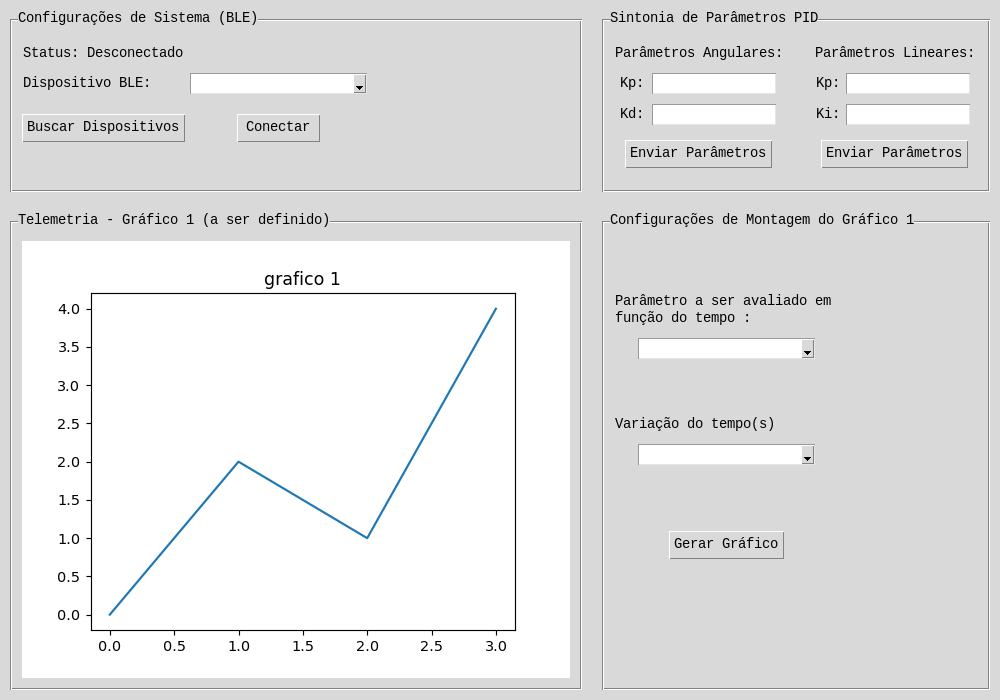

In [5]:

"""
Para que o código seja aberto no Google Colab, precisou importar novas bibliotecas
como o pyvirtualdisplay e pyscreenshot, visto que o Colab não possui um ambiente
de exibição direto.

"""
!pip install pyvirtualdisplay
!pip install pyscreenshot
import os
from pyvirtualdisplay import Display
display = Display(visible=1, size=(1000, 700), backend='xvfb')
display.start()
# Aqui configuramos o servidor

# Definir a variável de ambiente DISPLAY, se necessário
os.environ['DISPLAY'] = ':' + str(display.display) + '.0'


if __name__ == "__main__":
    app = AppTelemetria()
 # Força o Tkinter a desenhar a janela e seus widgets no display virtual
    app.update_idletasks()
    app.update()

    # Captura a tela do display virtual e exibe a imagem
    from PIL import Image
    import IPython.display
    from pyscreenshot import grab

    # Salva a captura de tela em um arquivo temporário e exibe
    filename = '/tmp/screenshot.png'
    # grab(bbox=(0,0,1000,700), to_file=filename, childprocess=False) # Original com erro
    image = grab(bbox=(0,0,1000,700), childprocess=False)
    image.save(filename)
    IPython.display.display(IPython.display.Image(filename))

    # Comentamos app.mainloop() pois ele bloquearia a execução no Colab
    # e a interação direta com a janela não é possível neste ambiente.
    # Se precisar de interação, seria necessário um setup de VNC ou desktop remoto.
